<a href="https://colab.research.google.com/github/FrancisDLopez/ml-prediccion-churn-cx/blob/main/notebooks/01_exploracion_nps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

# Fijar semilla para que los resultados sean los mismos siempre que lo ejecutes
np.random.seed(42)

n_clientes = 5000

# 1. Variables Transaccionales y Demográficas
cliente_id = np.arange(10000, 10000 + n_clientes)
edad = np.random.randint(18, 70, n_clientes)
antiguedad_meses = np.random.randint(1, 120, n_clientes)
saldo_promedio = np.round(np.random.exponential(scale=5000, size=n_clientes), 2)
num_productos = np.random.randint(1, 5, n_clientes)
morosidad_dias = np.random.choice([0, 15, 30, 60, 90], p=[0.7, 0.1, 0.1, 0.05, 0.05], size=n_clientes)

# 2. Variables de Experiencia del Cliente (Encuesta NPS)
prob_nps = [0.02, 0.02, 0.03, 0.03, 0.05, 0.10, 0.15, 0.15, 0.20, 0.15, 0.10]
nps_score = np.random.choice(np.arange(0, 11), p=prob_nps, size=n_clientes)

# Lógica estándar de categorización NPS
condiciones = [
    (nps_score >= 9),
    (nps_score >= 7) & (nps_score <= 8),
    (nps_score <= 6)
]
segmentos = ['Promotor', 'Neutro', 'Detractor']

# --- CORRECCIÓN APLICADA AQUÍ: Añadimos default='Desconocido' para unificar el tipo de dato a texto ---
nps_segmento = np.select(condiciones, segmentos, default='Desconocido')

# 3. Variable Objetivo (Churn) - Reglas lógicas de probabilidad
prob_churn = np.zeros(n_clientes)

# Factores de riesgo
prob_churn += np.where(nps_segmento == 'Detractor', 0.40, 0)
prob_churn += np.where(morosidad_dias > 30, 0.30, 0)
prob_churn += np.where(saldo_promedio < 500, 0.15, 0)

# Factores de retención
prob_churn -= np.where(nps_segmento == 'Promotor', 0.25, 0)
prob_churn -= np.where(num_productos > 2, 0.10, 0)

# Añadir ruido estadístico y limitar
prob_churn = np.clip(prob_churn + np.random.normal(0, 0.1, n_clientes), 0.05, 0.95)
churn = np.random.binomial(1, prob_churn)

# 4. Consolidar y Exportar
df_churn = pd.DataFrame({
    'cliente_id': cliente_id,
    'edad': edad,
    'antiguedad_meses': antiguedad_meses,
    'saldo_promedio': saldo_promedio,
    'num_productos': num_productos,
    'morosidad_dias': morosidad_dias,
    'nps_score': nps_score,
    'nps_segmento': nps_segmento,
    'churn': churn
})

# Generar el archivo CSV
df_churn.to_csv('dataset_churn_nps.csv', index=False)
print("¡Éxito! Dataset generado y guardado como 'dataset_churn_nps.csv'.")

¡Éxito! Dataset generado y guardado como 'dataset_churn_nps.csv'.


Datos cargados exitosamente. Total de clientes analizados: 5000



/tmp/ipykernel_2421/2550361709.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='nps_segmento', y='churn', data=df, errorbar=None, palette='viridis', order=['Detractor', 'Neutro', 'Promotor'])


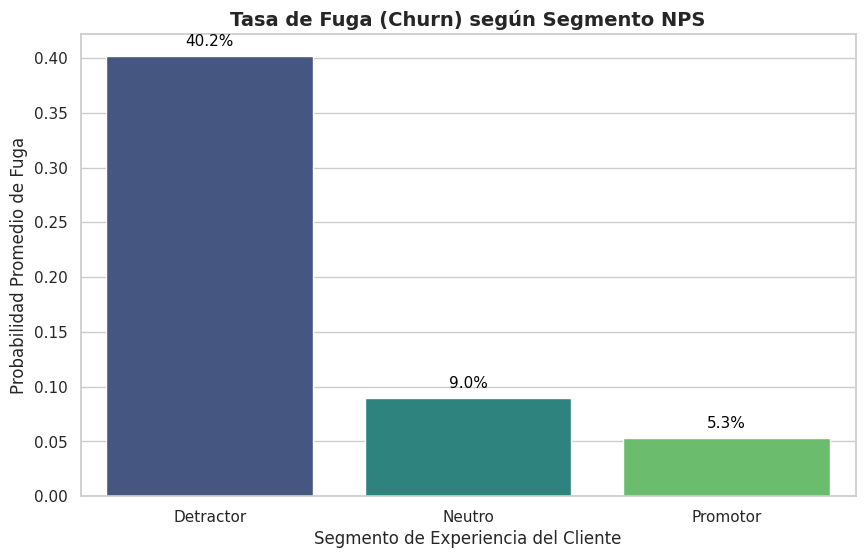

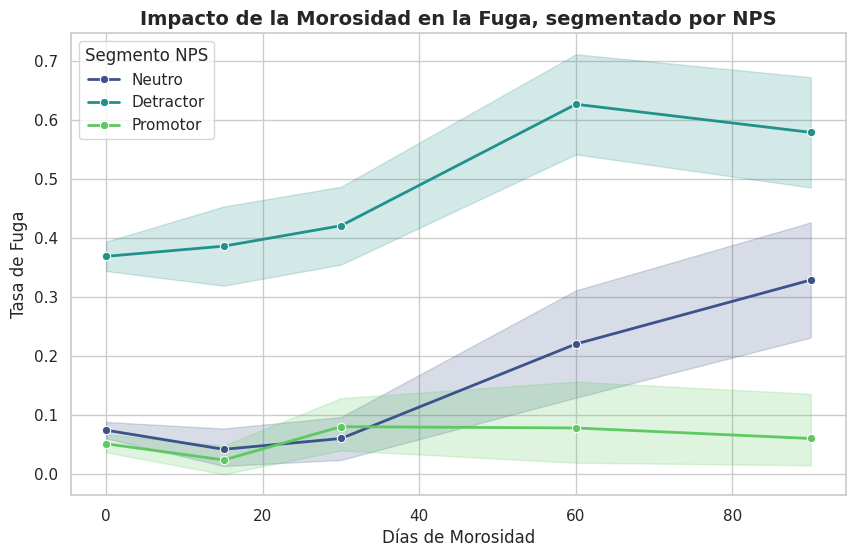

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo visual profesional
sns.set_theme(style="whitegrid")

# 1. Cargar los datos directamente desde tu rama 'main' en GitHub
url = 'https://raw.githubusercontent.com/FrancisDLopez/ml-prediccion-churn-cx/main/data/raw/dataset_churn_nps.csv'
df = pd.read_csv(url)

print(f"Datos cargados exitosamente. Total de clientes analizados: {df.shape[0]}\n")

# 2. Gráfico 1: Tasa de Fuga según Segmento NPS
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='nps_segmento', y='churn', data=df, errorbar=None, palette='viridis', order=['Detractor', 'Neutro', 'Promotor'])
plt.title('Tasa de Fuga (Churn) según Segmento NPS', fontsize=14, fontweight='bold')
plt.ylabel('Probabilidad Promedio de Fuga', fontsize=12)
plt.xlabel('Segmento de Experiencia del Cliente', fontsize=12)

# Añadir etiquetas de porcentaje
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1%}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

# 3. Gráfico 2: Impacto cruzado (Morosidad + NPS vs Fuga)
plt.figure(figsize=(10, 6))
sns.lineplot(x='morosidad_dias', y='churn', hue='nps_segmento', data=df, marker='o', palette='viridis', linewidth=2)
plt.title('Impacto de la Morosidad en la Fuga, segmentado por NPS', fontsize=14, fontweight='bold')
plt.ylabel('Tasa de Fuga', fontsize=12)
plt.xlabel('Días de Morosidad', fontsize=12)
plt.legend(title='Segmento NPS')
plt.show()